In [1]:
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pynauty

NUMBER_OF_GRAPHS = len(open("positive_graphs.g6").readlines())
print(f"Number of graphs: {NUMBER_OF_GRAPHS}")

Number of graphs: 4985


In [2]:
graphs = nx.read_graph6("positive_graphs.g6")
pynauty_graphs = []
nodes_counts = np.zeros(NUMBER_OF_GRAPHS)
for i, graph in enumerate(graphs):
    num_of_nodes = int(graph.number_of_nodes())
    nodes_counts[i] = num_of_nodes
    pynauty_graph = pynauty.Graph(num_of_nodes)
    pynauty_graph.set_adjacency_dict(dict(graph.adjacency()))
    pynauty_graphs.append((pynauty_graph, num_of_nodes, graph.edges()))

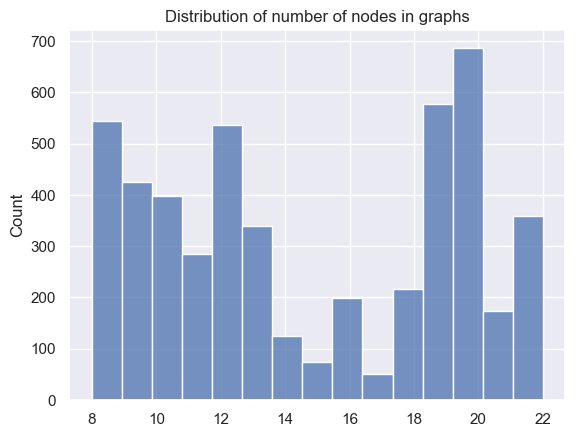

In [3]:
sns.set_theme()
sns.histplot(nodes_counts, bins=15).set(
    title="Distribution of number of nodes in graphs"
)
plt.show()

In [4]:
min_nodes = np.min(nodes_counts)
max_nodes = np.max(nodes_counts)
avg_nodes = np.mean(nodes_counts)
print(f"Min number of nodes: {min_nodes}")
print(f"Max number of nodes: {max_nodes}")
print(f"Avg number of nodes: {avg_nodes}")

Min number of nodes: 8.0
Max number of nodes: 22.0
Avg number of nodes: 14.66740220661986


In [5]:
group_sizes = np.zeros(NUMBER_OF_GRAPHS)
for i, (graph, num_of_nodes, edge_list) in enumerate(pynauty_graphs):
    generators_raw, grpsize1, grpsize2, _, _ = pynauty.autgrp(graph)
    group_size = grpsize1 * 10**grpsize2
    group_sizes[i] = group_size

In [6]:
min_group_size = np.min(group_sizes)
max_group_size = np.max(group_sizes)
avg_group_size = np.mean(group_sizes)
print(f"Min automorphism group size: {min_group_size}")
print(f"Max automorphism group size: {max_group_size}")
print(f"Avg automorphism group size: {avg_group_size}")

Min automorphism group size: 2.0
Max automorphism group size: 19200.0
Avg automorphism group size: 89.22627883650952


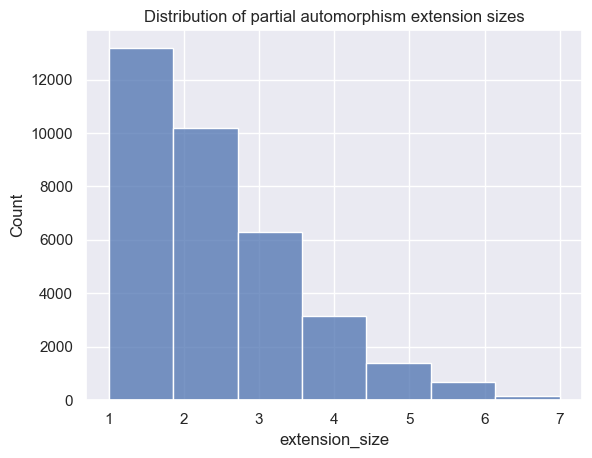

Min extension size: 1.0
Max extension size: 7
Avg extension size: 2.199143346659052


In [7]:
larger_dataset = pd.read_csv("paut_sizes.csv")
sns.set_theme()
sns.histplot(
    larger_dataset["extension_size"].where(larger_dataset["extension_size"] != 0),
    bins=7,
).set(title="Distribution of partial automorphism extension sizes")
plt.show()
min_extension_size = np.min(
    larger_dataset["extension_size"].where(larger_dataset["extension_size"] != 0)
)
max_extension_size = np.max(larger_dataset["extension_size"])
avg_extension_size = np.mean(
    larger_dataset["extension_size"].where(larger_dataset["extension_size"] != 0)
)
print(f"Min extension size: {min_extension_size}")
print(f"Max extension size: {max_extension_size}")
print(f"Avg extension size: {avg_extension_size}")

In [8]:
def get_stats(df, split_col="dataset_type"):
    rows = []
    for split, split_label in [
        ("train", "Training"),
        ("val", "Validation"),
        ("test", "Test"),
    ]:
        subset = df[df[split_col] == split]
        pos = subset[subset["extension_size"] == 0].shape[0]
        neg = subset[subset["extension_size"] > 0].shape[0]
        total = pos + neg
        ratio = f"{pos / neg:.4f}:1" if neg > 0 else "N/A"
        rows.append([split_label, total, pos, neg, ratio])
    return rows

In [9]:
smaller_dataset = pd.read_csv("baseline/paut_sizes_baseline.csv")
extended_features = pd.read_csv("7_features/paut_sizes_7_features.csv")
all_rows = (
    [["Baseline", *r] for r in get_stats(smaller_dataset)]
    + [["Extended Features", *r] for r in get_stats(extended_features)]
    + [["Larger", *r] for r in get_stats(larger_dataset)]
)

df = pd.DataFrame(
    all_rows, columns=["Dataset", "Split", "Total", "Positive", "Negative", "Ratio"]
)
# df.to_latex("dataset_stats.tex", index=False)
df

,Dataset,Split,Total,Positive,Negative,Ratio
0,Baseline,Training,46585,25908,20677,1.2530:1
1,Baseline,Validation,5754,3180,2574,1.2354:1
2,Baseline,Test,0,0,0,N/A
3,Extended Features,Training,46547,25908,20639,1.2553:1
4,Extended Features,Validation,5733,3180,2553,1.2456:1
5,Extended Features,Test,0,0,0,N/A
6,Larger,Training,70456,39336,31120,1.2640:1
7,Larger,Validation,8730,4830,3900,1.2385:1
8,Larger,Test,0,0,0,N/A


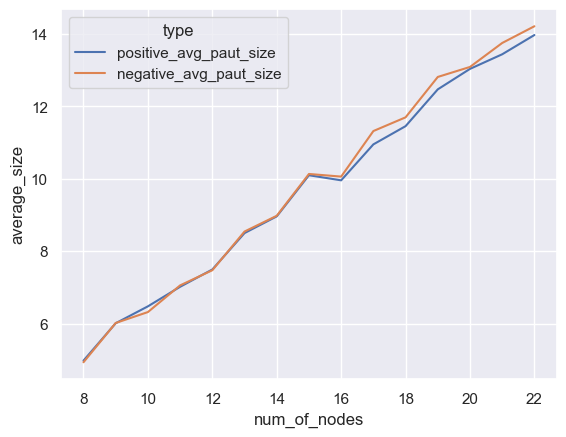

In [10]:
larger_dataset["total_paut_size"] = (
    larger_dataset["original_paut_size"] + larger_dataset["extension_size"]
)

positive_avg_paut_size = (
    larger_dataset[larger_dataset["extension_size"] == 0]
    .groupby("num_of_nodes")["original_paut_size"]
    .mean()
    .reset_index(name="positive_avg_paut_size")
)

negative_avg_paut_size = (
    larger_dataset[larger_dataset["extension_size"] != 0]
    .groupby("num_of_nodes")["total_paut_size"]
    .mean()
    .reset_index(name="negative_avg_paut_size")
)

plot_df = positive_avg_paut_size.merge(
    negative_avg_paut_size, on="num_of_nodes", how="outer"
)

plot_df = plot_df.melt(
    id_vars="num_of_nodes",
    value_vars=["positive_avg_paut_size", "negative_avg_paut_size"],
    var_name="type",
    value_name="average_size",
)

sns.lineplot(data=plot_df, x="num_of_nodes", y="average_size", hue="type")
plt.show()